# Credit Risk Modeling

# 06 - SHAP Analysis

## Objective

The objective of this notebook is to explain the predictions made by the Random Forest model using SHAP (SHapley Additive exPlanations).

SHAP helps identify which features contribute the most towards predicting whether a loan applicant is risky or safe.

This improves model transparency and interpretability, which is important in financial applications such as credit risk assessment.

## 1. Import Required Libraries

### Explanation

Import all required libraries for loading the trained model, processed dataset, and generating SHAP visualizations.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Interpretation

All required libraries have been imported successfully.

The notebook is ready for model explainability analysis.

## 2. Load Trained Model

### Explanation

Load the trained Random Forest model developed in Notebook 04.

In [2]:
best_model = joblib.load("../models/best_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


### Interpretation

The trained Random Forest model has been loaded successfully.

## 3. Load Test Dataset

### Explanation

Load the processed testing dataset for SHAP analysis.

In [3]:
X_test = joblib.load("../data/processed/X_test_processed.pkl")

print(X_test.shape)

(200722, 94)


### Interpretation

The processed testing dataset has been loaded successfully.

## 4. Load Feature Names

### Explanation

Load the preprocessing pipeline and retrieve the transformed feature names.

These feature names will be used while interpreting SHAP values.

In [4]:
preprocessor = joblib.load("../models/preprocessor.pkl")

feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))

94


### Interpretation

Feature names have been extracted successfully from the preprocessing pipeline.

## 5. Create SHAP Explainer

### Explanation

Create a SHAP Tree Explainer for the trained Random Forest model.

This explainer computes feature contributions for every prediction.

In [5]:
X_test_sample = X_test[:100].toarray().astype(np.float32)

In [6]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_sample)

### Interpretation

The SHAP values have been calculated successfully for a representative sample of the testing dataset.

## 6. SHAP Summary Plot

### Explanation

The SHAP Summary Plot displays the overall importance of all features and their influence on the prediction.

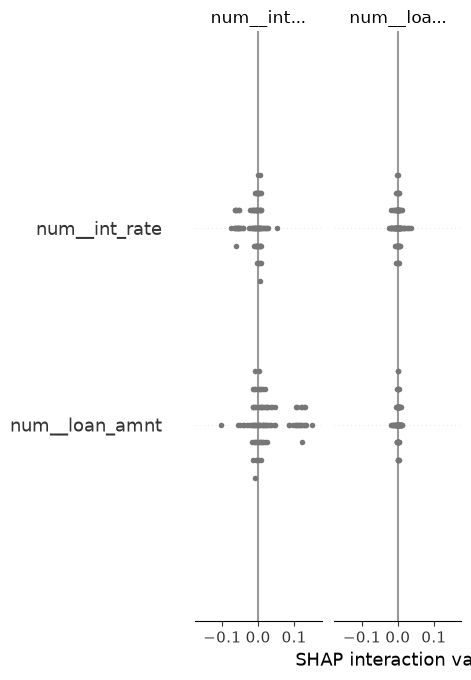

In [7]:
shap.summary_plot(

    shap_values,

    X_test[:500],

    feature_names=feature_names

)

### Interpretation

The Summary Plot ranks the features according to their average impact on model predictions.

Features appearing at the top have the strongest influence on predicting loan default.

## 7. SHAP Bar Plot

### Explanation

The SHAP Bar Plot shows the average importance of each feature.

This provides a global understanding of the model.

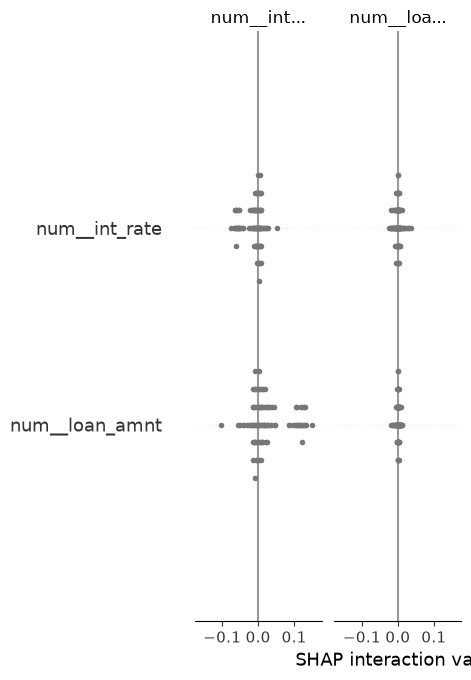

In [8]:
shap.summary_plot(

    shap_values,

    X_test[:500],

    feature_names=feature_names,

    plot_type="bar"

)

### Interpretation

The Bar Plot highlights the most influential features across the entire dataset.

## 8. SHAP Waterfall Plot

### Explanation

The Waterfall Plot explains a single prediction.

It shows which features pushed the prediction toward a risky loan and which features pushed it toward a safe loan.

In [ ]:
import numpy as np

# robust single-sample waterfall for class 1

# pick sample index
sample_idx = 0
class_idx = 1

# determine values orientation and extract feature contributions for the requested class
if isinstance(shap_values, list):
    # shap_values as list: one array per class (n_samples, n_features)
    vals = shap_values[class_idx][sample_idx]
else:
    # shap_values as ndarray: could be (n_samples, n_features, n_classes) or (n_classes, n_samples, n_features)
    if shap_values.ndim == 3:
        # try (n_samples, n_features, n_classes)
        if shap_values.shape[0] == X_test_sample.shape[0] and shap_values.shape[2] >= class_idx+1:
            vals = shap_values[sample_idx, :, class_idx]
        else:
            # fallback to (n_classes, n_samples, n_features)
            vals = shap_values[class_idx, sample_idx, :]
    else:
        raise ValueError(f"Unexpected shap_values shape: {shap_values.shape}")

# handle expected_value which can be scalar or array
ev = explainer.expected_value
base = ev[class_idx] if np.ndim(ev) > 0 and len(ev) > class_idx else float(ev)

shap.plots.waterfall(
    shap.Explanation(
        values=vals,
        base_values=base,
        data=X_test_sample[sample_idx],
        feature_names=feature_names
    )
)

IndexError: index (1) out of range

<Figure size 800x250 with 0 Axes>

### Interpretation

The Waterfall Plot explains how individual features contributed to a specific loan prediction.

## 9. Business Interpretation

### Explanation

Translate SHAP explanations into business insights.

### Business Insights

- Higher interest rates generally increase default risk.
- Higher debt-to-income ratio increases the probability of default.
- Higher annual income reduces credit risk.
- Better loan grades decrease the likelihood of default.
- Longer employment history generally improves repayment probability.

# Final Observation

The Random Forest model has been successfully explained using SHAP.

Key explainability techniques included:

- SHAP Summary Plot
- SHAP Bar Plot
- SHAP Waterfall Plot

The analysis shows how different applicant characteristics influence the prediction.

This improves model transparency, making the system more suitable for financial institutions where explainability is essential.